In [14]:
import pandas as pd
import numpy as np
import ast
import json
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer


In [15]:
df = pd.read_csv('../../data/test-final/master_dataset_for_training.csv')
print("Dataset loaded. Total records:", len(df))

Dataset loaded. Total records: 301


In [16]:
def parse_segments(segments_str):
    """
    Parse the segments field (which is a JSON string or Python literal)
    and return a list of segments as dictionaries.
    """
    if not isinstance(segments_str, str):
        return segments_str
    try:
        # First try using json.loads
        segments = json.loads(segments_str)
    except Exception:
        try:
            # Fallback: use ast.literal_eval if needed
            segments = ast.literal_eval(segments_str)
        except Exception as e:
            print("Error parsing segments:", e)
            return []
    return segments

In [17]:
def concatenate_candidate_text(segments_str):
    """
    Given a segments field, extract all 'text' values where speaker is "Candidate"
    and concatenate them into one string.
    """
    segments = parse_segments(segments_str)
    # Filter only candidate segments and concatenate their text with a separator (e.g., space)
    candidate_texts = [seg.get("text", "") for seg in segments if seg.get("speaker", "").lower() == "candidate"]
    full_text = " ".join(candidate_texts)
    return full_text

In [18]:
df['full_transcript_text'] = df['segments'].apply(concatenate_candidate_text)
print("Sample full transcript text:")
print(df['full_transcript_text'].iloc[0][:500])

Sample full transcript text:
good morning raj sounds great im excited learn role share experience course ive working fintech space 6 years current role asiacredit lead team develops deploys machine learning models credit risk assessment weve built several models using lightgbm xgboost predict customer churn default probability one project im particularly proud developing retention model reduced customer churn 18 six months used combination transaction data engagement metrics external economic indicators predict customers ri


###
 3. Compute Text Embeddings using SentenceTransformer

In [19]:
text_model = SentenceTransformer('all-MiniLM-L6-v2')
# Compute embeddings for each full transcript text
df['text_embedding'] = df['full_transcript_text'].apply(lambda x: text_model.encode(x, show_progress_bar=False))
print("Computed text embeddings for candidate transcripts.")


Computed text embeddings for candidate transcripts.


In [20]:
X_text = np.vstack(df['text_embedding'].values)
print("Text feature matrix shape:", X_text.shape)

Text feature matrix shape: (301, 384)


In [21]:
df['Overall_Score'] = df['Overall_Score'].astype(float)
y = df['Overall_Score'].values
print("Target vector shape:", y.shape)


Target vector shape: (301,)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X_text, y, test_size=0.3, random_state=42)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (210, 384)
Test set shape: (91, 384)


In [23]:
text_lr_model = LinearRegression()
text_lr_model.fit(X_train, y_train)
print("Text-only baseline model trained.")


Text-only baseline model trained.


In [24]:
y_train_pred = text_lr_model.predict(X_train)
y_test_pred = text_lr_model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Text-Only Baseline Model Performance:")
print(f"Train RMSE: {train_rmse:.3f}, Train R²: {train_r2:.3f}")
print(f"Test RMSE: {test_rmse:.3f}, Test R²: {test_r2:.3f}")

Text-Only Baseline Model Performance:
Train RMSE: 0.000, Train R²: 1.000
Test RMSE: 0.120, Test R²: 0.642


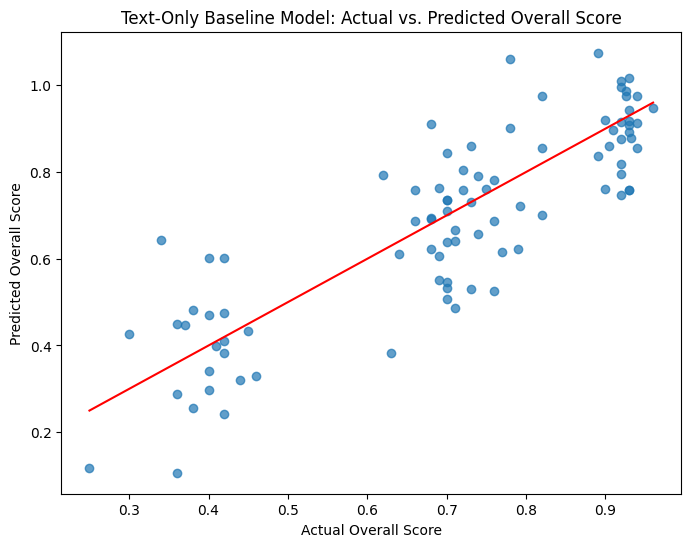

In [25]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7)
plt.xlabel("Actual Overall Score")
plt.ylabel("Predicted Overall Score")
plt.title("Text-Only Baseline Model: Actual vs. Predicted Overall Score")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # Diagonal line for reference
plt.show()